## Ratio-to-Trend Method: Viva Q&A

## Q1: What is the main purpose of this practical?
Answer: To isolate and measure the purely seasonal changes in a dataset by removing the underlying growth trend and random noise.

## Q2: What is the formula for Ratio-to-Trend?
Answer: (Actual Data Value / Mathematical Trend Value) * 100.

## Q3: Why do we divide the actual data by the trend value?
Answer: A time series contains Trend, Seasonality, and Noise ($Y = T \times S \times I$). If you divide $Y$ by the Trend ($T$), the trend cancels out mathematically, leaving only the Seasonality and Irregular Noise ($S \times I$).

## Q4: How do you eliminate the Irregular Noise?
Answer: By grouping the data by month (e.g., taking all the Januaries) and calculating their average. Averaging cancels out random positive and negative irregular shocks, leaving only the pure Seasonal Index.

## Q5: Why do we multiply the unadjusted indices by an adjustment factor?
Answer: The sum of all 12 monthly seasonal indices must exactly equal 1200 (since a perfectly flat average year is $100 \times 12$). We adjust them slightly so they perfectly sum up to this mathematical baseline.

## Q6: Look at your final bar chart. What does an index of 122 for July mean?
Answer: It means that, historically, passenger volume in July is 22% higher than a normal, average month, purely due to the summer vacation season.

Measurement of Seasonal Indicies by Ratio-to-Trend Method
Final Seasonal Indices
       Unadjusted_Index  Adjusted_Index
month                                  
Jan               93.02           92.14
Feb               91.10           90.25
Mar              103.29          102.32
Apr               99.81           98.87
May               99.16           98.22
Jun              111.78          110.72
Jul              123.84          122.68
Aug              122.52          121.37
Sep              105.88          104.88
Oct               92.09           91.22
Nov               79.69           78.94
Dec               89.24           88.40
 Sum_of_adjusted_indices: 1200.00


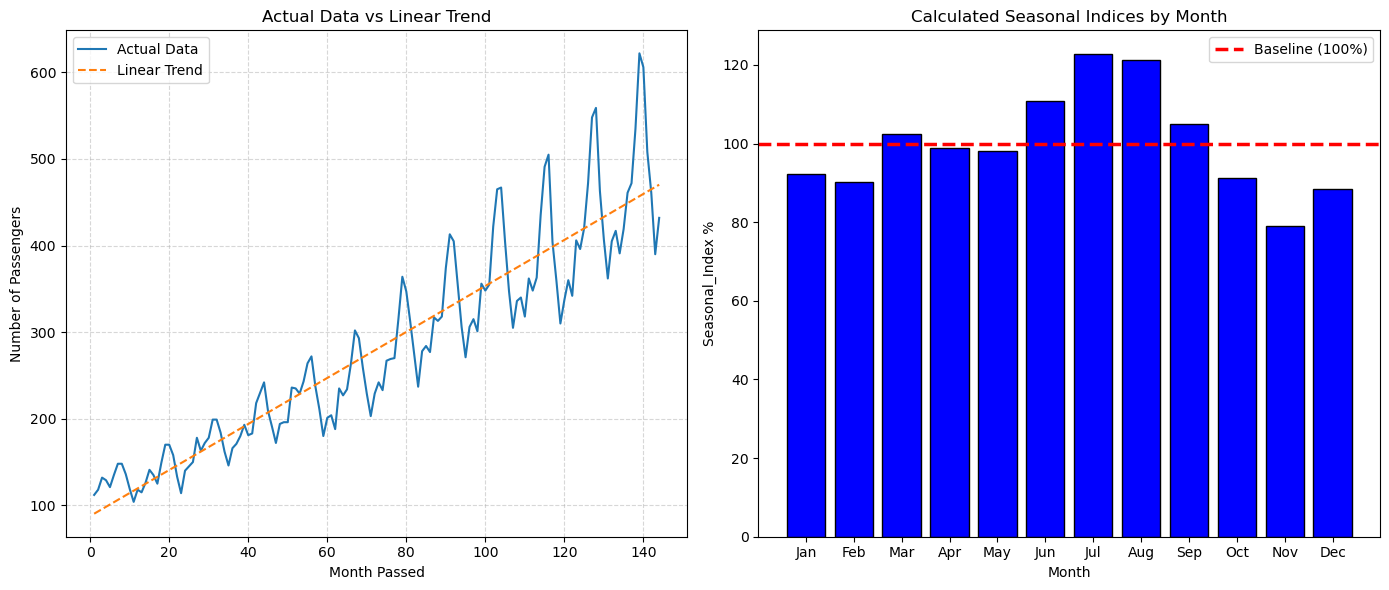

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 

warnings.filterwarnings("ignore")

def ratio_to_trend():
    print("Measurement of Seasonal Indicies by Ratio-to-Trend Method")
    df = sns.load_dataset("flights")
    df["time_index"] = np.arange(1,len(df)+1)

    slope,intercept = np.polyfit(df["time_index"],df["passengers"],1)
    df["trend_value"] = (slope*df["time_index"]) + intercept
    df["ratio_to_trend"] = (df["passengers"]/df["trend_value"]) * 100 

    unadjusted_indices = df.groupby("month")["ratio_to_trend"].mean()
    total_unadjusted = unadjusted_indices.sum()
    adjustment_factor = 1200/total_unadjusted
    adjusted_indices = unadjusted_indices * adjustment_factor

    result_df = pd.DataFrame({"Unadjusted_Index":unadjusted_indices,"Adjusted_Index":adjusted_indices}).round(2)
    print("Final Seasonal Indices")
    print(result_df)
    print(f" Sum_of_adjusted_indices: {adjusted_indices.sum():.2f}") # it should be 1200

    fig, axes = plt.subplots(1,2,figsize=(14,6))

    axes[0].plot(df["time_index"],df["passengers"],label="Actual Data")
    axes[0].plot(df["time_index"],df["trend_value"],label="Linear Trend",linestyle="--")
    axes[0].set_title("Actual Data vs Linear Trend")
    axes[0].set_xlabel("Month Passed")
    axes[0].set_ylabel("Number of Passengers")
    axes[0].legend()
    axes[0].grid(True,linestyle="--",alpha=0.5)

    axes[1].bar(adjusted_indices.index,adjusted_indices.values,color="blue",edgecolor="black")
    axes[1].axhline(y=100,linestyle="--",linewidth=2.5,color="red",label="Baseline (100%)")
    axes[1].set_title("Calculated Seasonal Indices by Month")
    axes[1].set_xlabel("Month")
    axes[1].set_ylabel("Seasonal_Index %")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    ratio_to_trend()